# **MET Computer Vision with Deep Learning**
## Visual Recognition
## Lab1 - Image classification using the Bag of Visual Words Model

2021-24 - Veronica Vilaplana - [GPI @ IDEAI](https://imatge.upc.edu/web/) Research group // [ETSETB – UPC.TelecosBCN](https://telecos.upc.edu/ca)

The goal of this laboratory work is to solve an image classification problem using the Bag of Visual Words model for image representation.


We will learn how to
1.   Detect and describe keypoints using SIFT
2.   Create a dictionary of visual words
3.   Represent an image with a histogram of visual words
4.   Train and test an image classifier based on the BOW representation

In the first part of this notebook code is provided to solve the task using SIFT keypoints and a k-NN classifier.

Then, you will have to complete some tasks, changing some of the hyperparemeters, computing other metrics or using a different classifier.

Instructions:
1. You can work in teams of two.
2. <font color=blue>**There are four mandatory tasks (required to pass the assignment) and one optional task (for extra credit).**</font>
3. Add and run your Python code and answer the questions in this same notebook.
5. Upload a zip file with the notebook (after running code cells, including results, confussion matrices, images, etc.) to Atenea.

---

### Write here your names

**Name1**: Enric Rubio Pacho

**Name2**: Agnès Felip i Díaz

---

We will use a dataset of images and files with image names of the images for the training and test splits.

First, download from ATENEA the file BOW_data.zip. Upload it to the Colab notebook using the menu on the left.

You could also copy the file to your Google drive and mount your drive in the colaboratory environment using:
>from google.colab import drive

>drive.mount('/content/drive')


Unzip the file:

In [1]:
# !unzip BOW_data.zip

In [2]:
import pickle

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
   

We read the train and test image names and labels

In [3]:
def load_files(): 
    train_filenames = pickle.load(open('./train_filenames.dat','rb'))
    test_filenames = pickle.load(open('./test_filenames.dat','rb'))
    train_labels = pickle.load(open('./train_labels.dat','rb'))
    test_labels = pickle.load(open('./test_labels.dat','rb'))

    return train_filenames, test_filenames, train_labels, test_labels

In [4]:
filenames, test_filenames, train_labels, test_labels = load_files()

In [5]:
def cv2_imshow(img):
    # Assuming 'img' is a valid image array
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")  # optional: hides axis ticks
    plt.show()

We will detect and describe keypoints using SIFT

But before creating the dictionary, let's compute and display the keypoints for a single sample image

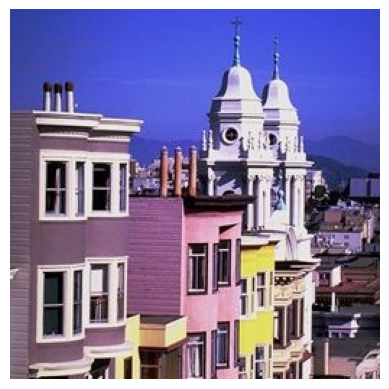

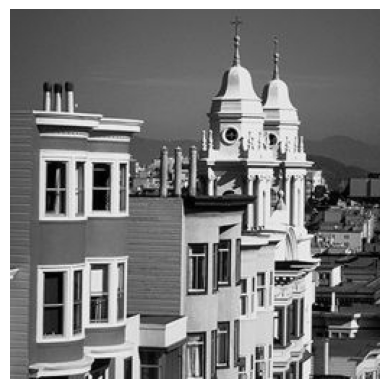

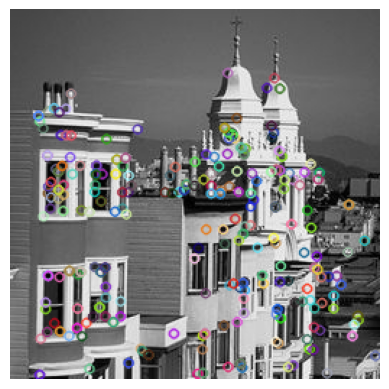

In [6]:
img = cv2.imread('./train/inside_city/a48009.jpg')
cv2_imshow(img)

gray= cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

#SIFTdetector = cv2.xfeatures2d.SIFT_create(nfeatures=300)

SIFTdetector = cv2.SIFT_create(300)
kpt=SIFTdetector.detect(gray,None)
img2=cv2.drawKeypoints(gray,kpt,img)
cv2_imshow(img)

Now we start to create the dictionary of visual words by detecting keypoints and computing the SIFT descriptors for all the training images

In [7]:
def compute_SIFT_descriptors(train_filenames, train_labels, detector):
    Train_descriptors = []
    Train_label_per_descriptor = []
    for filename,labels in zip(train_filenames,train_labels):
        ima=cv2.imread('./' +  filename)
        gray=cv2.cvtColor(ima,cv2.COLOR_BGR2GRAY)
        kpt,des=detector.detectAndCompute(gray,None)
        Train_descriptors.append(des)
        Train_label_per_descriptor.append(labels)

    D=np.vstack(Train_descriptors)

    return Train_descriptors, D

In [8]:
detector = cv2.SIFT_create(300)
descriptors, D = compute_SIFT_descriptors(filenames, train_labels, detector)

Next, we apply k-means clustering on the descriptor space. The cluster centers form the dictionary of visual words.

We will use `MiniBatchKMeans`, a variant of the KMeans algorithm which uses mini-batches to reduce the computation time.

`n_clusters` is the number of clusters or visual words in the dictionary. You can change this value to see the efect of using bigger or smaller dictionaries.

In [11]:
def fit_KMeans(D, n_clusters=100, verbose=False, compute_labels=False, reassignment_ratio=10**-4, random_state=42, n_init=3):
    """
    Fit KMeans to the data D.
    Parameters
    ----------
    D : array-like, shape (n_samples, n_features)
        Data to cluster.
    n_clusters : int, optional 
        The number of clusters to form as well as the number of centroids to generate.
        Default is 100.
    verbose : bool, optional
        Whether to print progress messages. Default is False.
    compute_labels : bool, optional
        Whether to compute labels for the data points. Default is False.
    reassignment_ratio : float, optional
        The fraction of points to reassign in each iteration. Default is 10^-4.
    random_state : int, optional
        Determines random number generation for centroid initialization. Use an int to make the randomness deterministic. Default is 42.
    n_init : int, optional
        Number of time the k-means algorithm will be run with different centroid seeds. Default is 3.
    Returns
    -------
    kmeans : object
        The fitted KMeans object.
    """
    kmeans =  MiniBatchKMeans(n_clusters=n_clusters, verbose=verbose, batch_size=n_clusters * 20, compute_labels=compute_labels, reassignment_ratio=reassignment_ratio, random_state=random_state, n_init=n_init)  
    kmeans.fit(D)
    return kmeans

In [13]:
n_clusters = 128
codebook = fit_KMeans(D, n_clusters=n_clusters)
codebook.cluster_centers_

array([[18.376188 ,  9.307937 ,  7.9178014, ...,  6.248414 ,  5.223407 ,
        12.034754 ],
       [22.689322 , 13.755258 , 10.690269 , ...,  8.262686 ,  5.9875255,
         9.107155 ],
       [21.30046  , 17.708506 , 19.156809 , ...,  9.980998 , 13.217172 ,
        15.56625  ],
       ...,
       [39.027374 , 26.018333 , 13.336029 , ...,  6.8306375,  4.7603106,
        10.004982 ],
       [22.033941 , 24.181889 , 22.17977  , ..., 29.61903  , 26.53501  ,
        24.651922 ],
       [75.84335  , 31.31405  ,  9.527933 , ...,  9.572244 ,  8.6279   ,
        15.687348 ]], dtype=float32)

In [14]:
def project_descriptors_to_visual_word(descriptors, codebook, n_clusters, scaler):
    """
    Project SIFT descriptors to visual words using the codebook.
    Parameters
    ----------
    descriptors : list of array-like, shape (n_samples, n_features)
        List of SIFT descriptors for each image.
    codebook : objectç
        The fitted KMeans object.
    Returns
    -------
    visual_words : array-like, shape (n_samples, n_clusters)
        The visual words for each image.
    """
    visual_words=np.zeros((len(descriptors),n_clusters),dtype=np.float32)
    for i in range(len(descriptors)):
        words=codebook.predict(descriptors[i])
        visual_words[i,:]=np.bincount(words,minlength=n_clusters)

    if scaler is not None:
        visual_words = scaler.fit_transform(visual_words)

    return visual_words

For each training image, we project each keypoint descriptor to its closest visual word. We represent each of the images with the frequency of each visual word.

In [15]:
visual_words = project_descriptors_to_visual_word(descriptors, codebook, n_clusters, None)

We create a k-nn classifier and train it with the training set histograms (Note that we use 'knn = KNeighborsClassifier`to create the classifier, and knn.fit for t

In [16]:
def classify(model, words, labels):
    model.fit(words, labels)

In [17]:
knn = KNeighborsClassifier(n_neighbors=5,n_jobs=-1,metric='euclidean')
classify(knn, visual_words, train_labels)

We compute the histograms for the test images, classify and compute the accuracy

In [18]:
def compute_histograms(filenames, codebook, n_clusters, scaler, detector, mode):
    """
    Compute histograms of visual words for each image.
    Parameters
    ----------
    filenames : list of str
        List of training image filenames.
    codebook : object
        The fitted KMeans object.
    Returns
    -------
    histograms : array-like, shape (n_samples, n_clusters)
        The histograms of visual words for each image.
    """
    histograms = np.zeros((len(filenames), n_clusters), dtype=np.float32)
    
    for i, filename in enumerate(filenames):
        img = cv2.imread('./' + filename)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        if (mode == 'dense'):
            height, width = gray.shape
            step_size = 10
            keypoints = []
            for y in range(0, height, step_size):
                for x in range(0, width, step_size):
                    keypoints.append(cv2.KeyPoint(x, y, step_size))
            
            # Compute SIFT descriptors at each keypoint
            _, des = detector.compute(gray, keypoints)
        else:
            _, des = detector.detectAndCompute(gray, None)
        
        words = codebook.predict(des)
        histograms[i, :] = np.bincount(words, minlength=n_clusters)

    if scaler is not None:
        histograms = scaler.transform(histograms)
    
    return histograms

In [19]:
visual_words_test = compute_histograms(test_filenames, codebook, n_clusters, None, detector, 'weak')

In [20]:
print ('example of a histogram of visual words (representation of image i):')
print (visual_words_test[0,:])

example of a histogram of visual words (representation of image i):
[2. 6. 0. 0. 0. 3. 8. 0. 3. 3. 1. 0. 2. 3. 1. 1. 1. 2. 3. 1. 1. 4. 4. 1.
 3. 6. 6. 0. 0. 1. 3. 2. 3. 0. 2. 0. 2. 2. 4. 2. 3. 0. 4. 3. 1. 2. 0. 3.
 0. 5. 1. 1. 0. 2. 1. 0. 1. 1. 8. 0. 0. 2. 2. 3. 3. 1. 0. 0. 2. 4. 2. 4.
 3. 0. 0. 6. 2. 4. 1. 0. 3. 5. 3. 2. 1. 0. 8. 0. 1. 0. 3. 7. 0. 4. 1. 0.
 4. 1. 0. 1. 4. 1. 0. 0. 4. 0. 0. 5. 3. 1. 4. 1. 1. 2. 0. 0. 0. 2. 3. 1.
 1. 0. 2. 3. 0. 1. 2. 1.]


In [21]:
accuracy = 100*knn.score(visual_words_test, test_labels)
print(accuracy)

predicted_labels = knn.predict(visual_words_test)
accuracy2 = accuracy_score(test_labels, predicted_labels)
print(accuracy2)

53.159851301115246
0.5315985130111525


## Tasks



1. Compute the confusion matrix and balanced accuracy. Which are the easiest and the most difficult classes? (import confusion_matrix or plot_confusion_matrix and balanced_accuracy_score from sklearn.metrics)
2. Test different codebook sizes and different values of neighbors in k-NN. Compare and report your best results.
3. Use a linear SVM classifier (use sklearn StandardScaler to standardize features).
4. (Optional) Use another variant of SVM: (1) with RBF kernel, (2) with histogram intersection kernel.
Use sklearn `StandardScaler` to standardize features.
5. Use Dense SIFT instead of detected keypoints. Report your best results and compare with results using detected keypoints.
6. Conclusions: Write a few paragraphs summarizing your work, results and conclusions from this assignment






<font color=red>1.   Compute the confusion matrix and balanced accuracy. Which are the easiest and the most difficult classes?

Import `confusion_matrix` or `plot_confusion_matrix` and `balanced_accuracy_score` from sklearn.metrics)</font><br>

In [22]:

def compute_stats(labels, predicted): 
    conf_m = confusion_matrix(labels, predicted) 
    d = ConfusionMatrixDisplay(confusion_matrix=conf_m, display_labels=np.unique(labels))
    d.plot(xticks_rotation="vertical")
    plt.show()

    report = classification_report(labels, predicted) 
    print(report)
    
    balanced_acc = balanced_accuracy_score(labels, predicted)
    print(balanced_acc)

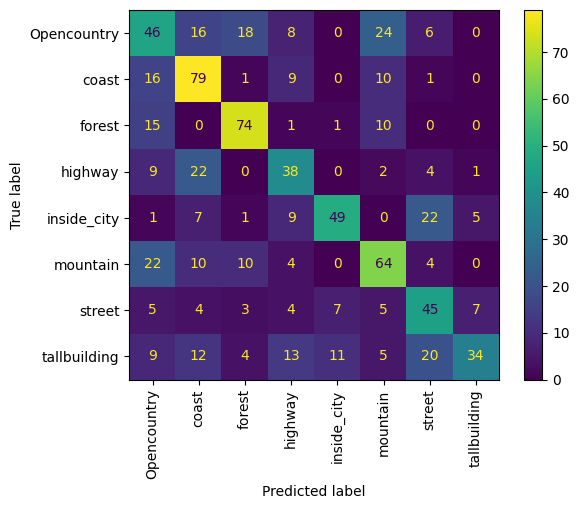

              precision    recall  f1-score   support

 Opencountry       0.37      0.39      0.38       118
       coast       0.53      0.68      0.59       116
      forest       0.67      0.73      0.70       101
     highway       0.44      0.50      0.47        76
 inside_city       0.72      0.52      0.60        94
    mountain       0.53      0.56      0.55       114
      street       0.44      0.56      0.49        80
tallbuilding       0.72      0.31      0.44       108

    accuracy                           0.53       807
   macro avg       0.55      0.53      0.53       807
weighted avg       0.56      0.53      0.53       807

0.5329416472364195


In [23]:
compute_stats(test_labels, predicted_labels)

<font color=white>
The easiest class we have is Forest with a 0.74 F1-score, followed by Inside city 0.62 and Coast with 0.6. For the more difficult classes to predict, we have Opencountry with an F1-score of 0.39, then Tallbuilding with 0.41 and street with 0.49
</font><br>

<font color=red>2.   Test different codebook sizes and different values of neighbors in k-NN.

Compare and report your best results. You can also try using different distances.</font><br>

In [24]:
# Your code here
def run_model(model, D, k, descriptors, train_labels, test_filenames, test_labels, scaler, detector, mode):
    print(f"Training model with {model.__class__.__name__}...")
    print(f"Number of clusters: {k}")
    print(f"Number of training samples: {len(train_labels)}")
    print(f"Number of test samples: {len(test_labels)}")
    print(f"Number of features: {D.shape[1]}")
    print(f"Number of descriptors: {len(descriptors)}")    
    print(f"Using scaler: {scaler.__class__.__name__ if scaler else 'None'}")
    print(f"Using SIFT detector mode: {mode}")


    codebook = fit_KMeans(D, n_clusters=k)
    codebook.cluster_centers_
    
    visual_words = project_descriptors_to_visual_word(descriptors, codebook, k, scaler)

    classify(model, visual_words, train_labels)
    
    visual_words_test = compute_histograms(test_filenames, codebook, k, scaler, detector, mode)  
    predicted_labels = model.predict(visual_words_test)   
    
    compute_stats(test_labels, predicted_labels)


Running KNN with k=64 and n_neighbors=1...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: weak


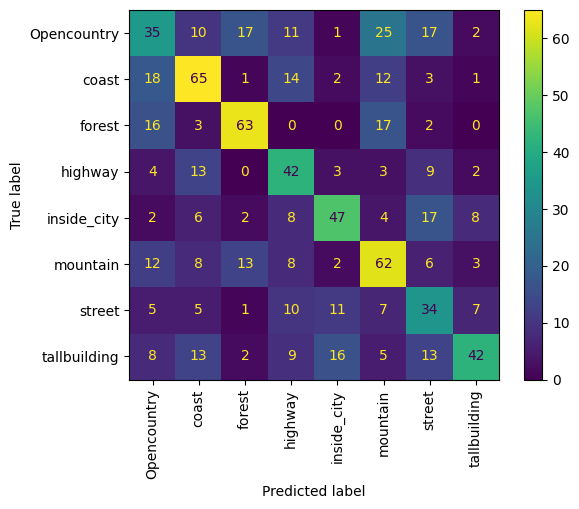

              precision    recall  f1-score   support

 Opencountry       0.35      0.30      0.32       118
       coast       0.53      0.56      0.54       116
      forest       0.64      0.62      0.63       101
     highway       0.41      0.55      0.47        76
 inside_city       0.57      0.50      0.53        94
    mountain       0.46      0.54      0.50       114
      street       0.34      0.42      0.38        80
tallbuilding       0.65      0.39      0.49       108

    accuracy                           0.48       807
   macro avg       0.49      0.49      0.48       807
weighted avg       0.50      0.48      0.48       807

0.48638718628430255
Running KNN with k=64 and n_neighbors=3...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: weak


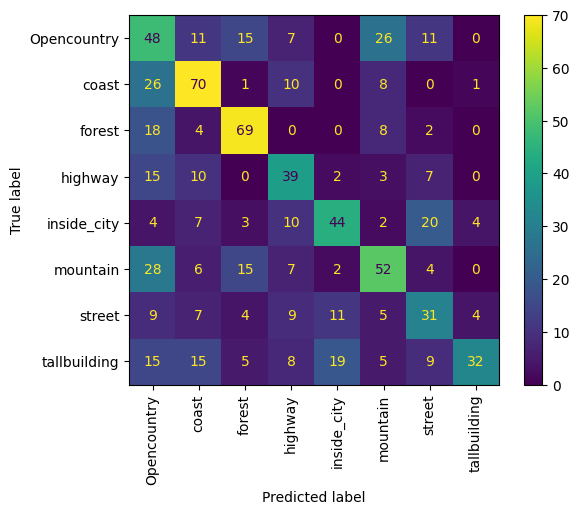

              precision    recall  f1-score   support

 Opencountry       0.29      0.41      0.34       118
       coast       0.54      0.60      0.57       116
      forest       0.62      0.68      0.65       101
     highway       0.43      0.51      0.47        76
 inside_city       0.56      0.47      0.51        94
    mountain       0.48      0.46      0.47       114
      street       0.37      0.39      0.38        80
tallbuilding       0.78      0.30      0.43       108

    accuracy                           0.48       807
   macro avg       0.51      0.48      0.48       807
weighted avg       0.51      0.48      0.48       807

0.47682198775050144
Running KNN with k=64 and n_neighbors=5...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: weak


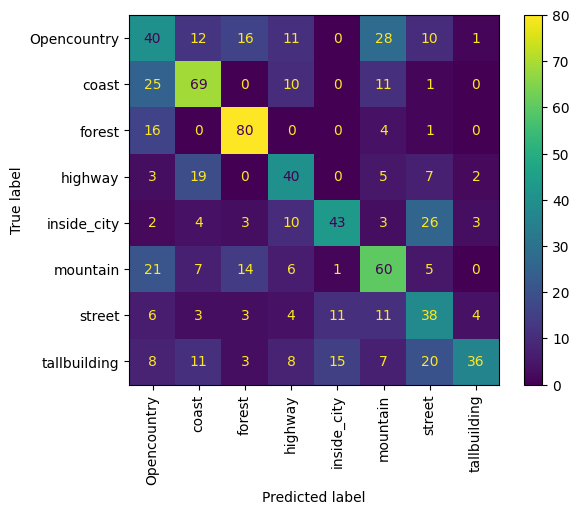

              precision    recall  f1-score   support

 Opencountry       0.33      0.34      0.33       118
       coast       0.55      0.59      0.57       116
      forest       0.67      0.79      0.73       101
     highway       0.45      0.53      0.48        76
 inside_city       0.61      0.46      0.52        94
    mountain       0.47      0.53      0.49       114
      street       0.35      0.47      0.40        80
tallbuilding       0.78      0.33      0.47       108

    accuracy                           0.50       807
   macro avg       0.53      0.51      0.50       807
weighted avg       0.53      0.50      0.50       807

0.5055376957208108
Running KNN with k=128 and n_neighbors=1...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: weak


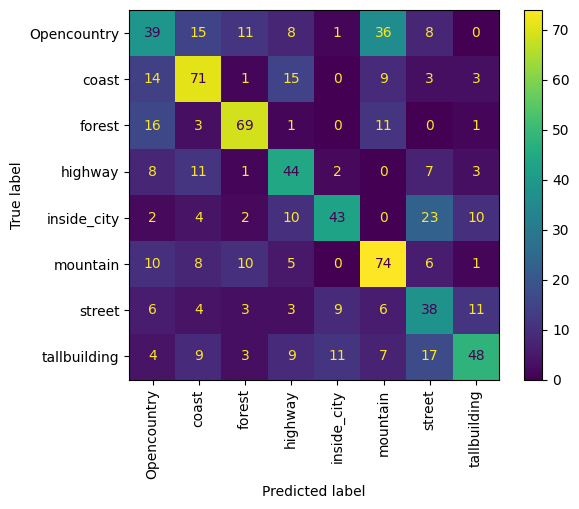

              precision    recall  f1-score   support

 Opencountry       0.39      0.33      0.36       118
       coast       0.57      0.61      0.59       116
      forest       0.69      0.68      0.69       101
     highway       0.46      0.58      0.51        76
 inside_city       0.65      0.46      0.54        94
    mountain       0.52      0.65      0.58       114
      street       0.37      0.47      0.42        80
tallbuilding       0.62      0.44      0.52       108

    accuracy                           0.53       807
   macro avg       0.54      0.53      0.52       807
weighted avg       0.54      0.53      0.53       807

0.5288383981648594
Running KNN with k=128 and n_neighbors=3...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: weak


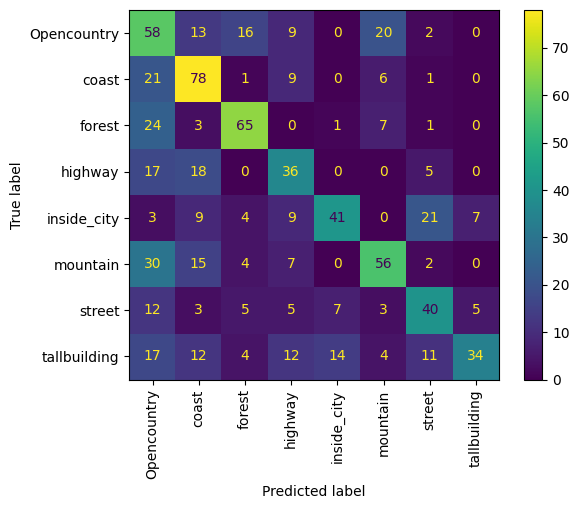

              precision    recall  f1-score   support

 Opencountry       0.32      0.49      0.39       118
       coast       0.52      0.67      0.58       116
      forest       0.66      0.64      0.65       101
     highway       0.41      0.47      0.44        76
 inside_city       0.65      0.44      0.52        94
    mountain       0.58      0.49      0.53       114
      street       0.48      0.50      0.49        80
tallbuilding       0.74      0.31      0.44       108

    accuracy                           0.51       807
   macro avg       0.55      0.50      0.51       807
weighted avg       0.55      0.51      0.51       807

0.502925110193804
Running KNN with k=128 and n_neighbors=5...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: weak


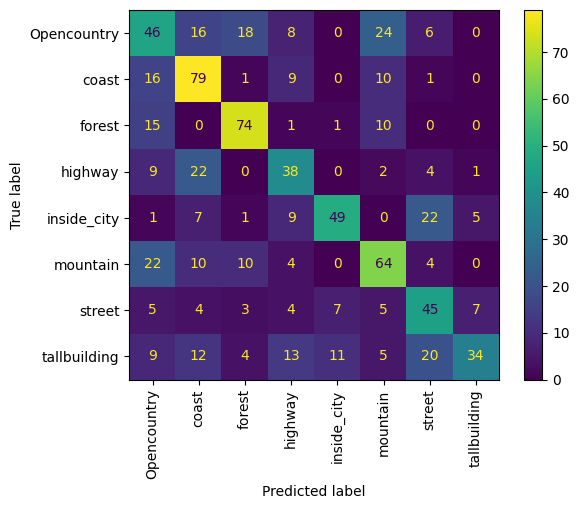

              precision    recall  f1-score   support

 Opencountry       0.37      0.39      0.38       118
       coast       0.53      0.68      0.59       116
      forest       0.67      0.73      0.70       101
     highway       0.44      0.50      0.47        76
 inside_city       0.72      0.52      0.60        94
    mountain       0.53      0.56      0.55       114
      street       0.44      0.56      0.49        80
tallbuilding       0.72      0.31      0.44       108

    accuracy                           0.53       807
   macro avg       0.55      0.53      0.53       807
weighted avg       0.56      0.53      0.53       807

0.5329416472364195
Running KNN with k=256 and n_neighbors=1...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: weak


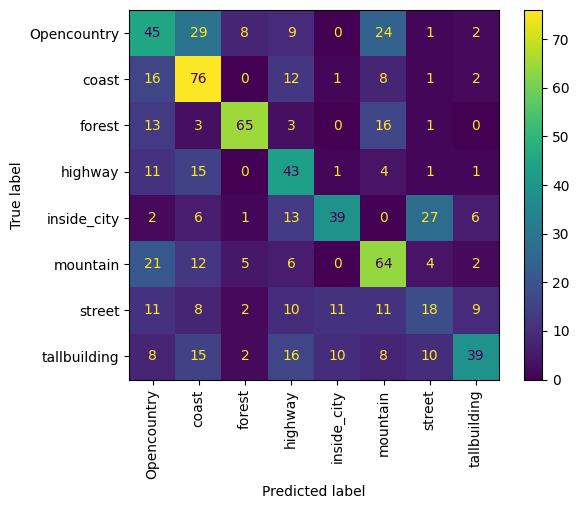

              precision    recall  f1-score   support

 Opencountry       0.35      0.38      0.37       118
       coast       0.46      0.66      0.54       116
      forest       0.78      0.64      0.71       101
     highway       0.38      0.57      0.46        76
 inside_city       0.63      0.41      0.50        94
    mountain       0.47      0.56      0.51       114
      street       0.29      0.23      0.25        80
tallbuilding       0.64      0.36      0.46       108

    accuracy                           0.48       807
   macro avg       0.50      0.48      0.48       807
weighted avg       0.51      0.48      0.48       807

0.4760363016275831
Running KNN with k=256 and n_neighbors=3...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: weak


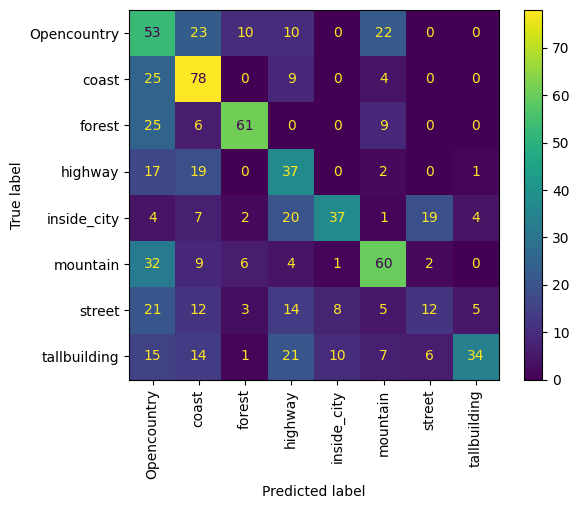

              precision    recall  f1-score   support

 Opencountry       0.28      0.45      0.34       118
       coast       0.46      0.67      0.55       116
      forest       0.73      0.60      0.66       101
     highway       0.32      0.49      0.39        76
 inside_city       0.66      0.39      0.49        94
    mountain       0.55      0.53      0.54       114
      street       0.31      0.15      0.20        80
tallbuilding       0.77      0.31      0.45       108

    accuracy                           0.46       807
   macro avg       0.51      0.45      0.45       807
weighted avg       0.52      0.46      0.46       807

0.4496395577930233
Running KNN with k=256 and n_neighbors=5...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: weak


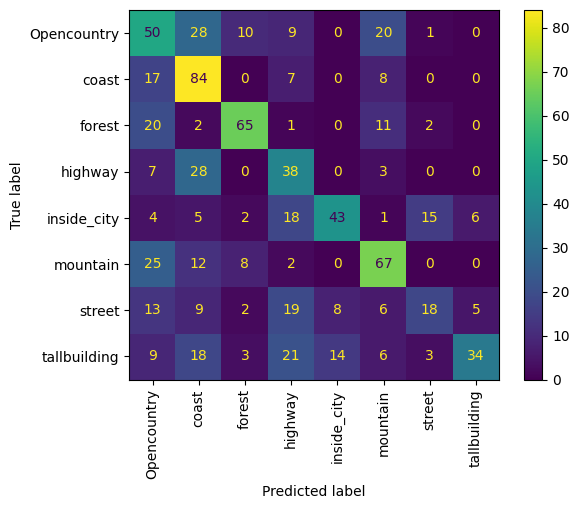

              precision    recall  f1-score   support

 Opencountry       0.34      0.42      0.38       118
       coast       0.45      0.72      0.56       116
      forest       0.72      0.64      0.68       101
     highway       0.33      0.50      0.40        76
 inside_city       0.66      0.46      0.54        94
    mountain       0.55      0.59      0.57       114
      street       0.46      0.23      0.30        80
tallbuilding       0.76      0.31      0.44       108

    accuracy                           0.49       807
   macro avg       0.53      0.48      0.48       807
weighted avg       0.54      0.49      0.49       807

0.4845515028250645


In [27]:
train_filenames, test_filenames, train_labels, test_labels = load_files()
SIFTdetector = cv2.SIFT_create(300)
Train_descriptors, D = compute_SIFT_descriptors(train_filenames, train_labels, SIFTdetector)
for k in [64, 128, 256]:
    for knn_n in [1, 3, 5]:
        print(f"Running KNN with k={k} and n_neighbors={knn_n}...")
        knn = KNeighborsClassifier(n_neighbors=knn_n,n_jobs=-1,metric='euclidean')
        run_model(knn, D, k, Train_descriptors, train_labels, test_filenames, test_labels, None , SIFTdetector, 'weak')

<font color=blue>2. Answer:  </font><br>


<font color=red>3. Use a linear SVM classifier. Use sklearn `StandardScaler` to standardize features (removing the mean and scaling to unit variance).</font><br>

Training model with SVC...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: StandardScaler
Using SIFT detector mode: weak


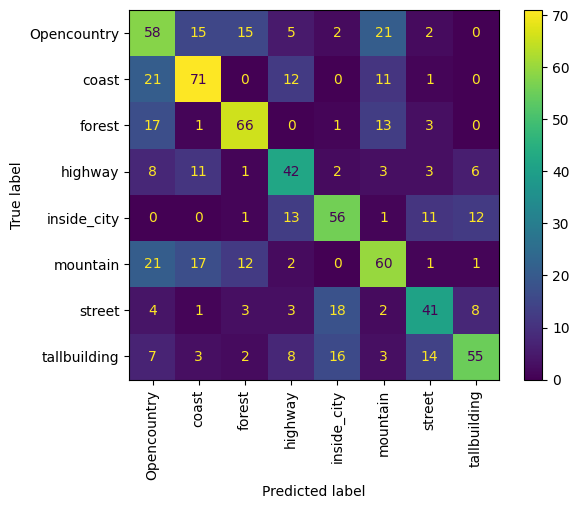

              precision    recall  f1-score   support

 Opencountry       0.43      0.49      0.46       118
       coast       0.60      0.61      0.60       116
      forest       0.66      0.65      0.66       101
     highway       0.49      0.55      0.52        76
 inside_city       0.59      0.60      0.59        94
    mountain       0.53      0.53      0.53       114
      street       0.54      0.51      0.53        80
tallbuilding       0.67      0.51      0.58       108

    accuracy                           0.56       807
   macro avg       0.56      0.56      0.56       807
weighted avg       0.56      0.56      0.56       807

0.5566888805390104


In [28]:
# Your code here to compute the codebook and histograms for training images
train_filenames, test_filenames, train_labels, test_labels = load_files()
SIFTdetector = cv2.SIFT_create(300)
descriptors, D = compute_SIFT_descriptors(filenames, train_labels, SIFTdetector)
svm = SVC(kernel='linear')
scaler = StandardScaler()
run_model(svm, D, 128, Train_descriptors, train_labels, test_filenames, test_labels, scaler,SIFTdetector, 'weak')

<font color=blue>3. Answer:  </font><br>

<font color=red>4. (optional) Use another variant of SVM: (1) with RBF kernel, (2) with histogram intersection kernel.
Use sklearn `StandardScaler` to standardize features.</font><br>

Training model with SVC...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: StandardScaler
Using SIFT detector mode: weak


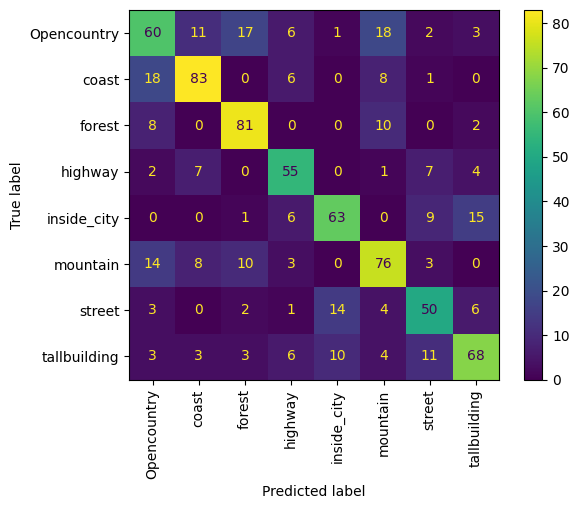

              precision    recall  f1-score   support

 Opencountry       0.56      0.51      0.53       118
       coast       0.74      0.72      0.73       116
      forest       0.71      0.80      0.75       101
     highway       0.66      0.72      0.69        76
 inside_city       0.72      0.67      0.69        94
    mountain       0.63      0.67      0.65       114
      street       0.60      0.62      0.61        80
tallbuilding       0.69      0.63      0.66       108

    accuracy                           0.66       807
   macro avg       0.66      0.67      0.66       807
weighted avg       0.66      0.66      0.66       807

0.6676456610562947


In [29]:
# Your code here to compute the codebook and histograms for training images
train_filenames, test_filenames, train_labels, test_labels = load_files()
SIFTdetector = cv2.SIFT_create(300)
descriptors, D = compute_SIFT_descriptors(filenames, train_labels, SIFTdetector)
svm = SVC(kernel='rbf')
scaler = StandardScaler()
run_model(svm, D, 128, Train_descriptors, train_labels, test_filenames, test_labels, scaler, SIFTdetector, 'weak')

Training model with SVC...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: StandardScaler
Using SIFT detector mode: weak


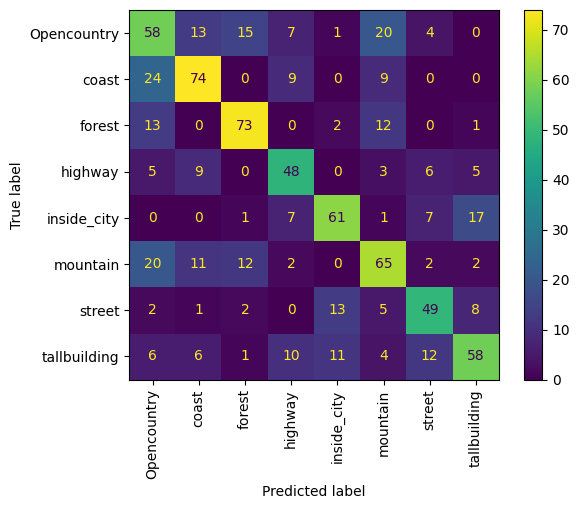

              precision    recall  f1-score   support

 Opencountry       0.45      0.49      0.47       118
       coast       0.65      0.64      0.64       116
      forest       0.70      0.72      0.71       101
     highway       0.58      0.63      0.60        76
 inside_city       0.69      0.65      0.67        94
    mountain       0.55      0.57      0.56       114
      street       0.61      0.61      0.61        80
tallbuilding       0.64      0.54      0.58       108

    accuracy                           0.60       807
   macro avg       0.61      0.61      0.61       807
weighted avg       0.61      0.60      0.60       807

0.6065570410817512


In [30]:
def histogram_intersection_kernel(X, Y=None):
    """
    Compute the histogram intersection kernel between X and Y.
    K(x, y) = sum(min(x_i, y_i))
    
    Parameters
    ----------
    X : array-like, shape (n_samples_X, n_features)
        First set of samples.
    Y : array-like, shape (n_samples_Y, n_features), optional
        Second set of samples. If None, Y=X.
    
    Returns
    -------
    K : array-like, shape (n_samples_X, n_samples_Y)
        Kernel matrix.
    """
    return pairwise_kernels(X, Y, metric=lambda x, y: np.sum(np.minimum(x, y)))

train_filenames, test_filenames, train_labels, test_labels = load_files()
SIFTdetector = cv2.SIFT_create(300)
descriptors, D = compute_SIFT_descriptors(filenames, train_labels, SIFTdetector)
svm = SVC(kernel=histogram_intersection_kernel)
scaler = StandardScaler()
run_model(svm, D, 128, Train_descriptors, train_labels, test_filenames, test_labels, scaler, SIFTdetector, 'weak')

<font color=blue>4. Answer:  </font><br>

<font color=red>5. Use Dense SIFT instead of detected keypoints. Report your best results and compare with results using detected keypoints.</font><br>


Training model with SVC...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: StandardScaler
Using SIFT detector mode: dense


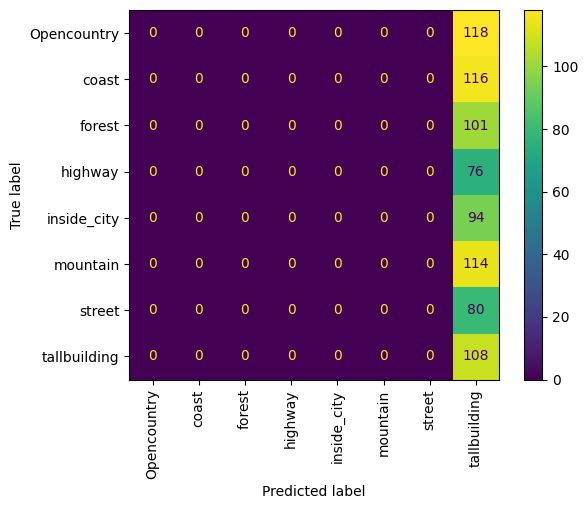

              precision    recall  f1-score   support

 Opencountry       0.00      0.00      0.00       118
       coast       0.00      0.00      0.00       116
      forest       0.00      0.00      0.00       101
     highway       0.00      0.00      0.00        76
 inside_city       0.00      0.00      0.00        94
    mountain       0.00      0.00      0.00       114
      street       0.00      0.00      0.00        80
tallbuilding       0.13      1.00      0.24       108

    accuracy                           0.13       807
   macro avg       0.02      0.12      0.03       807
weighted avg       0.02      0.13      0.03       807

0.125


/home/enric/Master/cvdl/cvdl-labs/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/enric/Master/cvdl/cvdl-labs/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/enric/Master/cvdl/cvdl-labs/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

In [31]:
# Your code here to compute the codebook and histograms for training images
train_filenames, test_filenames, train_labels, test_labels = load_files()
SIFTdetector = cv2.SIFT_create(300)
descriptors, D = compute_SIFT_descriptors(filenames, train_labels, SIFTdetector)
svm = SVC(kernel='rbf')
scaler = StandardScaler()
run_model(svm, D, 128, Train_descriptors, train_labels, test_filenames, test_labels, scaler, SIFTdetector, 'dense')

<font color=blue>5. Answer:  </font><br>

<font color=blue>Conclusions:

Write a few paragraphs summarizing your work, results and conclussions from this assignment</font><br>

